# Matplotlib A to Z — The Complete Reference Notebook (Explained Simply)

This notebook explains Matplotlib — Python's main plotting library — from
the basics all the way to the specialized plots used in machine learning
work. Everything is explained in plain, everyday language, using simple
examples like exam scores, heights, weather, and basic fake datasets. No
function or attribute is used without first being explained in easy
words.

**How to read this notebook**

Read the text above each code cell first — it explains, in simple terms,
what the code is about to do and why you would want to do it. Then run
the cell to see the picture it produces. Every example in this notebook
builds its own small dataset, so nothing external is needed to run it.

**Table of Contents**

1. Essential Core Concepts
2. Critical Plots for Exploratory Data Analysis (EDA)
3. Specialized Plots for Machine Learning and AI
4. Quick Reference Cheat-Sheet


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


print("Matplotlib version:", matplotlib.__version__)

Matplotlib version: 3.10.0


## 1. Essential Core Concepts

### What is Matplotlib, in simple words?

Matplotlib is a Python library used to turn numbers into pictures — line
charts, bar charts, scatter plots, and many other kinds of graphs. If
you have ever made a chart in Excel by selecting some numbers and
clicking "Insert Chart", Matplotlib does the same basic job, except you
control it by writing code, which means you can automate it, customize
it precisely, and reuse it again and again.

### Figure and Axes — the two most important building blocks

Before drawing anything, you need to understand two words that Matplotlib
uses constantly:

- **Figure** — think of the Figure as the entire blank page, canvas, or
  picture frame. It is the whole window that everything gets drawn
  inside. A single Figure can be empty, or it can contain one chart, or
  many charts side by side.
- **Axes** — despite the confusing name (it is NOT the same as
  "axis", like an x-axis or y-axis), an "Axes" is one individual chart
  or plot area sitting inside the Figure. If the Figure is the whole
  page, an Axes is one drawing on that page. A Figure can hold many
  Axes at once, arranged in a grid — this is how you make a "multi-panel"
  layout, for example, showing original data next to a model's
  prediction, side by side.

`plt.subplots()` is the function you will use constantly to create a
Figure and one or more Axes at the same time, in one single line of code.


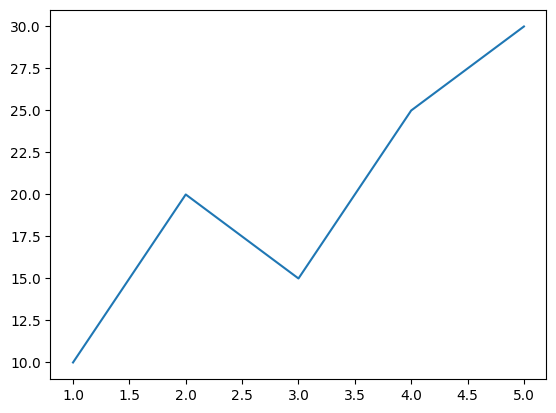

In [2]:
# The simplest possible case: one Figure containing exactly one Axes.
# plt.subplots() with no arguments gives you back TWO things:
#   fig  -> the whole page (the Figure)
#   ax   -> the single chart area inside it (the Axes)
fig, ax = plt.subplots()

x_values = [1, 2, 3, 4, 5]
y_values = [10, 20, 15, 25, 30]

ax.plot(x_values, y_values)   # draw a simple line on this Axes
plt.show()

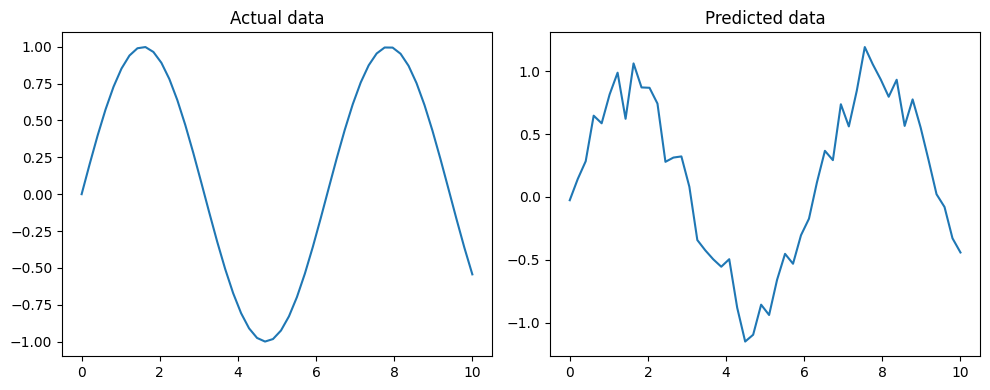

In [3]:
# Now let's create a MULTI-PANEL layout: one Figure containing several Axes,
# arranged in a grid. We ask for 1 row and 2 columns of charts, side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# 'axes' is now a LIST containing 2 Axes objects: axes[0] and axes[1]

x = np.linspace(0, 10, 50)
actual_values = np.sin(x)          # pretend this is the "real" data
predicted_values = np.sin(x) + np.random.normal(0, 0.15, size=50)   # pretend this is a "prediction" with some error

axes[0].plot(x, actual_values)
axes[0].set_title("Actual data")

axes[1].plot(x, predicted_values)
axes[1].set_title("Predicted data")

plt.tight_layout()   # automatically adds spacing so titles/labels don't overlap
plt.show()

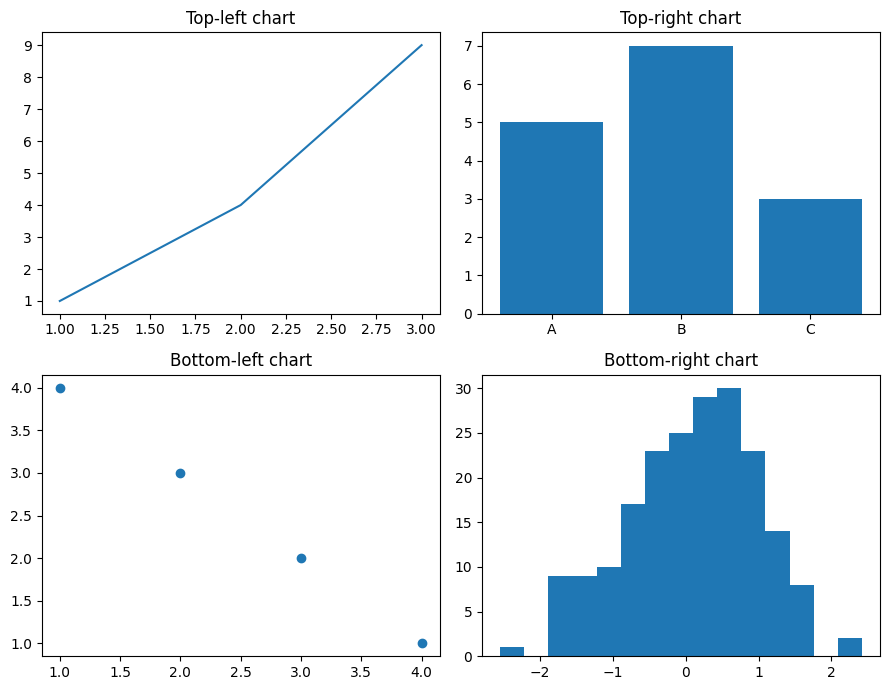

In [4]:
# A grid layout with rows AND columns: 2 rows, 2 columns = 4 Axes total.
# When you have more than one row, 'axes' becomes a GRID (rows x columns),
# so you access each chart with two positions: axes[row, column].
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

axes[0, 0].plot([1, 2, 3], [1, 4, 9])
axes[0, 0].set_title("Top-left chart")

axes[0, 1].bar(["A", "B", "C"], [5, 7, 3])
axes[0, 1].set_title("Top-right chart")

axes[1, 0].scatter([1, 2, 3, 4], [4, 3, 2, 1])
axes[1, 0].set_title("Bottom-left chart")

axes[1, 1].hist(np.random.randn(200), bins=15)
axes[1, 1].set_title("Bottom-right chart")

plt.tight_layout()
plt.show()

**A quick note on `plt.plot()` vs `ax.plot()`:** you will see both
styles used online. `plt.plot()` (calling the function directly on
`plt`) quietly draws on "whichever chart is currently active" — this is
fine for a single, quick chart. `ax.plot()` (calling it on a specific
Axes object you already have a handle on) is the more reliable style,
especially once you have more than one chart in the same Figure, because
there is no doubt about exactly which chart you are drawing on. This
notebook mostly uses the `ax.` style for that reason.

### Basic styling and labels — making a chart clear enough for a report

A chart with no title or axis labels forces the reader to guess what they
are looking at. These are the basic labeling tools you should use on
almost every chart:

- `.set_title()` — adds a title text above the chart.
- `.set_xlabel()` / `.set_ylabel()` — adds a label describing what the
  horizontal (x) and vertical (y) axes represent.
- `.legend()` — adds a small labeled box that explains what each line or
  set of points on the chart represents, when there is more than one.
- `.grid()` — adds light gridlines across the chart background, which
  makes it easier for the eye to read exact values.


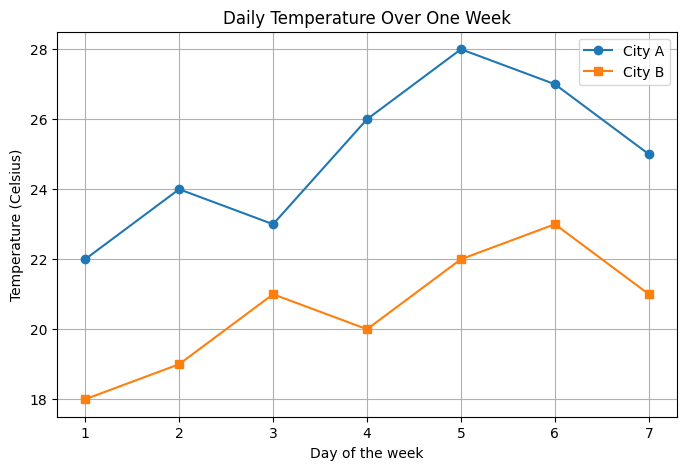

In [5]:
days = [1, 2, 3, 4, 5, 6, 7]
temperature_city_a = [22, 24, 23, 26, 28, 27, 25]
temperature_city_b = [18, 19, 21, 20, 22, 23, 21]

fig, ax = plt.subplots(figsize=(8, 5))

# The 'label' argument here is what shows up later in the legend
ax.plot(days, temperature_city_a, label="City A", marker="o")
ax.plot(days, temperature_city_b, label="City B", marker="s")

ax.set_title("Daily Temperature Over One Week")
ax.set_xlabel("Day of the week")
ax.set_ylabel("Temperature (Celsius)")
ax.legend()          # shows the "City A" / "City B" box, using the labels above
ax.grid(True)         # turns on the light background gridlines

plt.show()

### Saving high-resolution outputs — `plt.savefig()`

Once a chart looks the way you want, you will usually need to save it as
an actual image file — for a report, a research paper, or a slide.
`plt.savefig()` does this job.

- The file format is chosen automatically from the file name's ending:
  `.png` for a normal image, `.pdf` or `.svg` for a "vector" format that
  stays perfectly sharp at any zoom level (better for printed research
  papers).
- `dpi` stands for "dots per inch" — it controls the resolution (sharpness)
  of the saved image. A higher `dpi` gives a crisper image but a bigger
  file size. `dpi=300` is a common choice for print-quality output.
- `bbox_inches='tight'` trims away extra blank space around the edges of
  the saved image, so titles and labels don't get cut off.


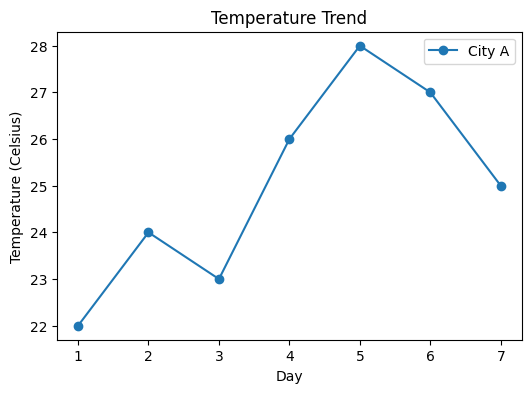

Saved as temperature_chart.png


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(days, temperature_city_a, label="City A", marker="o")
ax.set_title("Temperature Trend")
ax.set_xlabel("Day")
ax.set_ylabel("Temperature (Celsius)")
ax.legend()

# Saving as a sharp PNG image, with extra whitespace trimmed off
plt.savefig("temperature_chart.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved as temperature_chart.png")

## 2. Critical Plots for Exploratory Data Analysis (EDA)

"Exploratory Data Analysis" simply means looking at your data with plots
BEFORE doing any serious analysis or model training, just to understand
what it looks like, whether anything looks wrong, and what patterns might
already be visible.

### Scatter plots — spotting relationships between two variables

A scatter plot places one dot for every single data point, using one
variable for its left-right (x) position and another variable for its
up-down (y) position. It is the standard way to check whether two
variables seem to be related to each other, and to spot natural
groupings ("clusters") in the data.


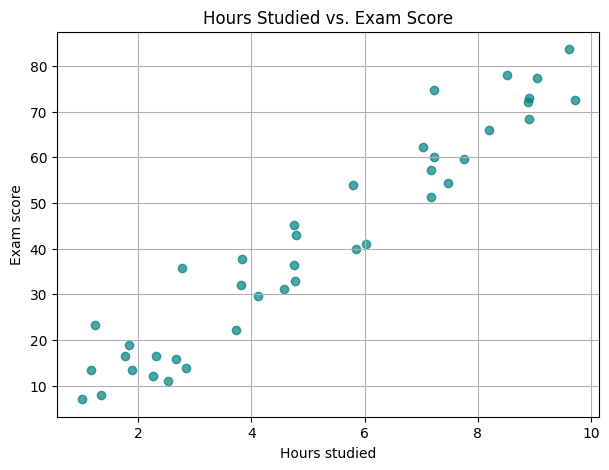

In [7]:
# Imagine we recorded each student's hours studied and the exam score they got.
np.random.seed(1)
hours_studied = np.random.uniform(1, 10, 40)
exam_score = hours_studied * 8 + np.random.normal(0, 8, 40)   # more hours -> generally higher score, with some randomness

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(hours_studied, exam_score, color="teal", alpha=0.7)
# alpha controls transparency: 1 = fully solid, 0 = fully invisible.
# A lower alpha helps you see overlapping points more clearly.

ax.set_title("Hours Studied vs. Exam Score")
ax.set_xlabel("Hours studied")
ax.set_ylabel("Exam score")
ax.grid(True)
plt.show()

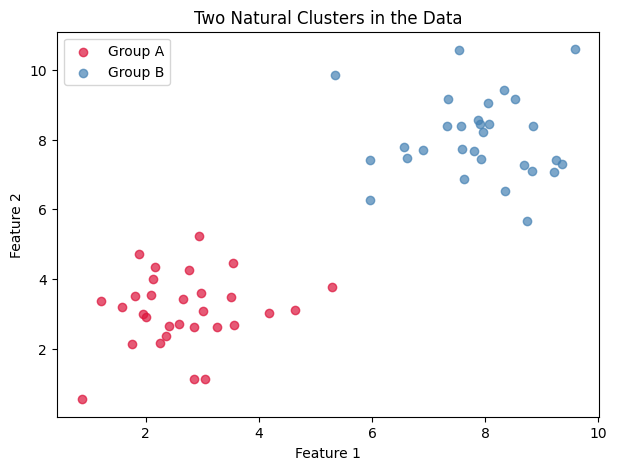

In [10]:
# A scatter plot can also show a THIRD piece of information using color,
# which is very useful for spotting groups/clusters in the data.
np.random.seed(2)
group_a_x = np.random.normal(3, 1, 30)
group_a_y = np.random.normal(3, 1, 30)
group_b_x = np.random.normal(8, 1, 30)
group_b_y = np.random.normal(8, 1, 30)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(group_a_x, group_a_y, color="crimson", label="Group A", alpha=0.7)
ax.scatter(group_b_x, group_b_y, color="steelblue", label="Group B", alpha=0.7)

ax.set_title("Two Natural Clusters in the Data")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
plt.show()

### Histograms — checking how your data is spread out

A histogram groups numbers into "buckets" (called bins) and draws a bar
for each bucket, showing how many data points fall inside it. It answers
the question: "Are most of my values low, high, or in the middle? Are
they spread out evenly, or bunched together?"

- `bins` — the number of buckets to split the data into. Too few bins
  hides detail; too many bins makes the shape look noisy and jagged.
- **Skewness** — a simple word for "lopsidedness". If a histogram has a
  long tail stretching out to the right, it is called "right-skewed"
  (most values are low, with a few very high ones pulling the tail out).
  The opposite is "left-skewed".


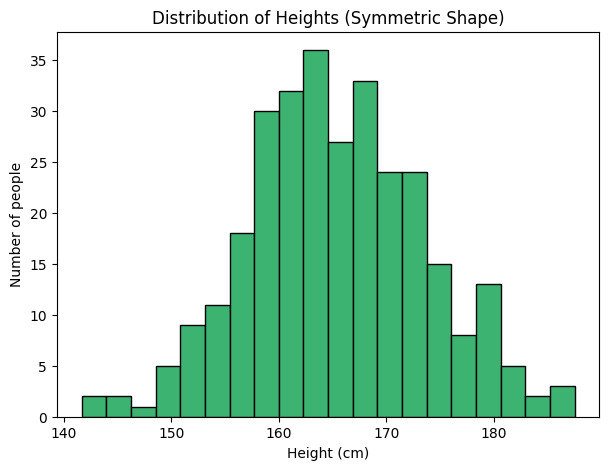

In [11]:
np.random.seed(3)
# A normal, evenly-spread ("symmetric") set of heights in centimeters
heights = np.random.normal(loc=165, scale=8, size=300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(heights, bins=20, color="mediumseagreen", edgecolor="black")

ax.set_title("Distribution of Heights (Symmetric Shape)")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Number of people")
plt.show()

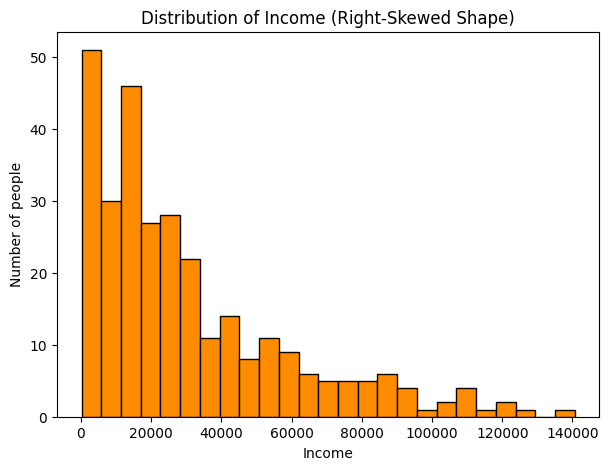

In [12]:
# A right-skewed example: most people earn a modest income, but a
# small number earn very high amounts, stretching the tail out to the right.
np.random.seed(4)
income = np.random.exponential(scale=30000, size=300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(income, bins=25, color="darkorange", edgecolor="black")

ax.set_title("Distribution of Income (Right-Skewed Shape)")
ax.set_xlabel("Income")
ax.set_ylabel("Number of people")
plt.show()

### Box plots — a compact summary that highlights outliers

A box plot summarizes a whole set of numbers using just a few key
markers, and it is one of the fastest ways to spot "outliers" (values
that are unusually far from the rest of the data).

Reading a box plot from bottom to top:

- The bottom line of the box is the **25th percentile** — 25% of the data
  falls below this point.
- The line through the middle of the box is the **median** — the exact
  middle value once everything is sorted.
- The top line of the box is the **75th percentile** — 75% of the data
  falls below this point.
- The thin lines extending above and below the box ("whiskers") show the
  normal range of the rest of the data.
- Individual dots plotted beyond the whiskers are the **outliers** —
  values so unusually high or low that they stand out from the rest.


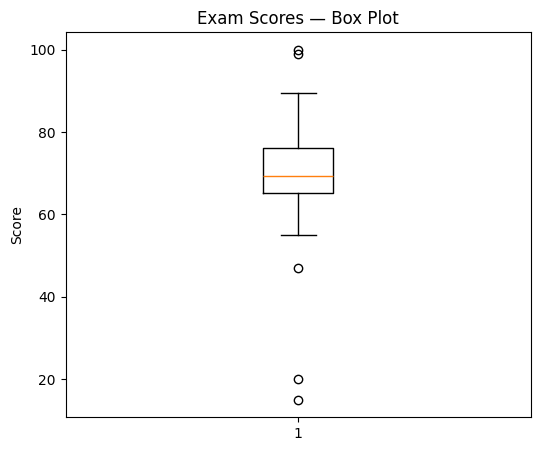

In [13]:
np.random.seed(5)
normal_scores = np.random.normal(70, 8, 95)
# Adding a handful of deliberately unusual, extreme scores to demonstrate outliers
outlier_scores = np.array([15, 20, 99, 100])
all_scores = np.concatenate([normal_scores, outlier_scores])

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(all_scores, vert=True)

ax.set_title("Exam Scores — Box Plot")
ax.set_ylabel("Score")
plt.show()

/tmp/ipykernel_3092/3790385443.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([class_a, class_b, class_c], labels=["Class A", "Class B", "Class C"])


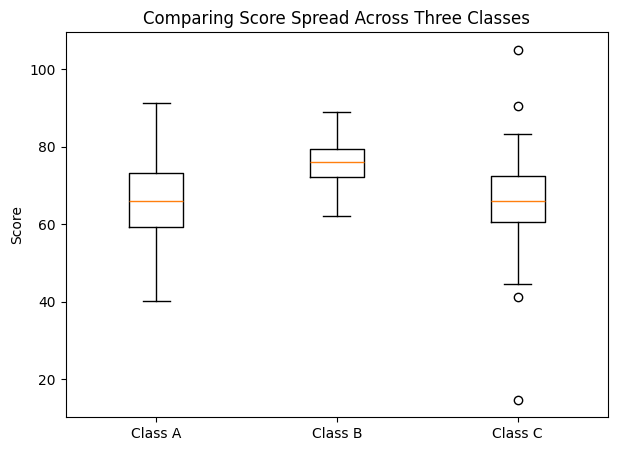

In [14]:
# Comparing several groups side by side is where box plots really shine.
np.random.seed(6)
class_a = np.random.normal(65, 10, 50)
class_b = np.random.normal(75, 6, 50)
class_c = np.random.normal(70, 15, 50)

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([class_a, class_b, class_c], labels=["Class A", "Class B", "Class C"])

ax.set_title("Comparing Score Spread Across Three Classes")
ax.set_ylabel("Score")
plt.show()

### Line plots — tracking how something changes over time or in sequence

A line plot connects data points in order with a line, which makes it
the natural choice whenever your data has a meaningful ORDER — most
commonly, time. It lets you see trends (going up, going down, staying
flat) at a glance.


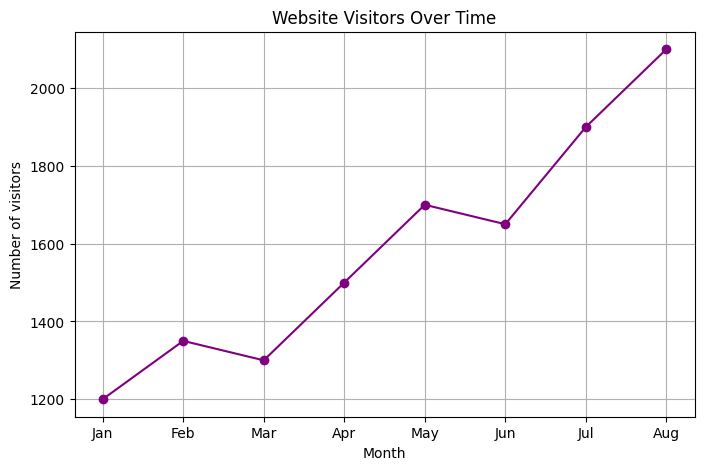

In [15]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug"]
website_visitors = [1200, 1350, 1300, 1500, 1700, 1650, 1900, 2100]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(months, website_visitors, marker="o", color="purple")

ax.set_title("Website Visitors Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of visitors")
ax.grid(True)
plt.show()

## 3. Specialized Plots for Machine Learning and AI

These plots are the ones you will see constantly once you start training
your own machine learning models. Each one answers a specific question
about how well a model is doing.

### Loss and accuracy curves — checking if a model is learning correctly

When you train a machine learning model, it usually trains over several
rounds called **epochs** (one epoch = one full pass through the training
data). At the end of each epoch, we record two numbers:

- **Loss** — a single number that measures how WRONG the model's
  predictions currently are. Lower is better. A loss of 0 would mean
  perfect predictions.
- **Accuracy** — the percentage of predictions the model got exactly
  right. Higher is better.

We track BOTH of these on the **training data** (the data the model
learns from) and on separate **validation data** (data the model never
directly learns from, used only to check how well it generalizes).
Plotting both lines together on the same chart, over each epoch, is one
of the most useful diagnostic tools in machine learning:

- If the training loss keeps dropping but the validation loss starts
  rising again, that is a classic sign of **overfitting** — the model is
  starting to just memorize the training data instead of learning
  patterns that generalize to new data.
- If both the training loss and validation loss stay high and barely
  improve, that is a sign of **underfitting** — the model is too simple,
  or hasn't trained for long enough, to learn the patterns in the data at
  all.


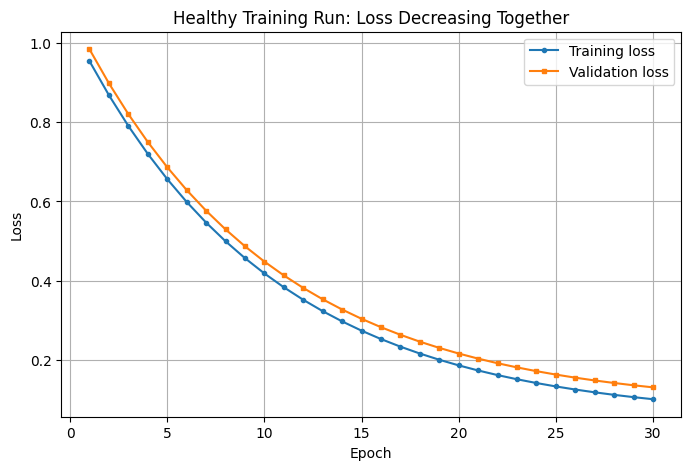

In [16]:
# Simulating fake training history for 30 epochs, just to demonstrate the plot.
# In a real project, these numbers would come from your model's actual training logs.
epochs = np.arange(1, 31)

# A HEALTHY training run: both losses go down together and level off
train_loss_healthy = 1.0 * np.exp(-epochs / 10) + 0.05
val_loss_healthy = 1.0 * np.exp(-epochs / 10) + 0.08

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_loss_healthy, label="Training loss", marker="o", markersize=3)
ax.plot(epochs, val_loss_healthy, label="Validation loss", marker="s", markersize=3)

ax.set_title("Healthy Training Run: Loss Decreasing Together")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)
plt.show()

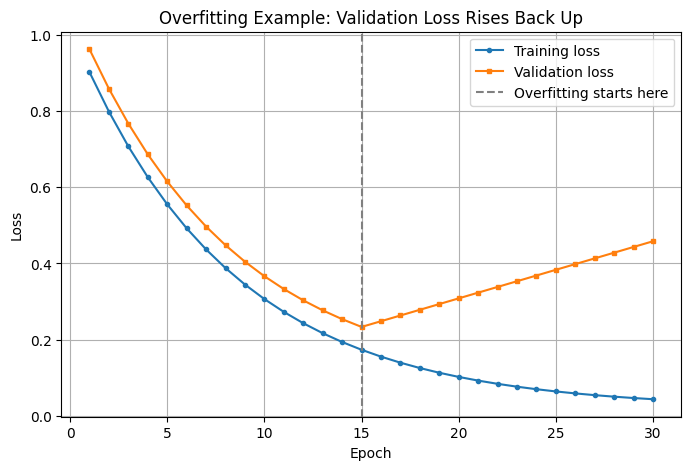

In [17]:
# An OVERFITTING example: training loss keeps improving, but validation loss
# starts rising back up after a certain point - the model is memorizing, not learning.
train_loss_overfit = 1.0 * np.exp(-epochs / 8) + 0.02
val_loss_overfit = np.concatenate([
    1.0 * np.exp(-epochs[:15] / 8) + 0.08,                      # improves at first...
    (1.0 * np.exp(-epochs[14] / 8) + 0.08) + (epochs[15:] - epochs[14]) * 0.015   # ...then gets worse
])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_loss_overfit, label="Training loss", marker="o", markersize=3)
ax.plot(epochs, val_loss_overfit, label="Validation loss", marker="s", markersize=3)

ax.axvline(x=15, color="gray", linestyle="--", label="Overfitting starts here")
# axvline draws a single vertical reference line at a chosen x position - useful
# for marking a specific point of interest on the chart.

ax.set_title("Overfitting Example: Validation Loss Rises Back Up")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)
plt.show()

### Confusion matrices — seeing exactly which classes a classifier confuses

A "classifier" is a model that sorts things into categories (for
example, sorting emails into "spam" or "not spam"). A confusion matrix is
a small table that shows, for every TRUE category, how many items the
model predicted for EACH possible category. It reveals exactly which
categories the model tends to mix up with each other, which a single
"accuracy" percentage cannot show you.

- `plt.imshow()` — displays a 2D array (a grid of numbers) as a colored
  image, where each number is converted into a color based on its size.
  This is exactly how a confusion matrix, or any "heatmap", gets drawn.
- `pcolor` (and its faster, modern relative `pcolormesh`) does a similar
  job to `imshow`, drawing a grid of colored rectangles from a 2D array of
  numbers — the main practical difference is that `pcolor`/`pcolormesh`
  can handle unevenly-spaced grid lines, while `imshow` assumes evenly
  spaced pixels, which makes `imshow` the simpler and more common choice
  specifically for confusion matrices.


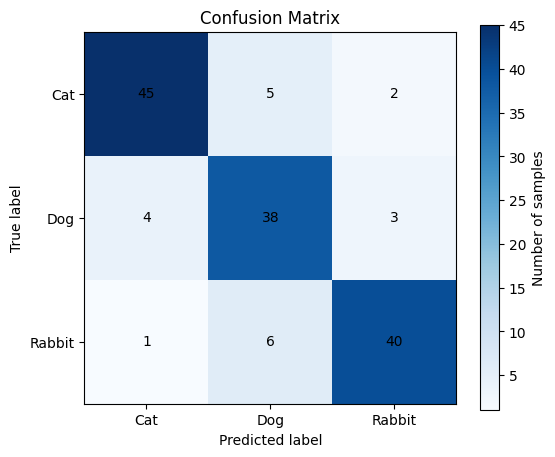

In [18]:
# A fake confusion matrix for a 3-class problem: Cat, Dog, Rabbit.
# Each ROW is the TRUE label, each COLUMN is what the model PREDICTED.
# Example: row 'Cat', column 'Dog' = 5 means "5 real cats were wrongly predicted as dogs".
confusion_matrix = np.array([
    [45,  5,  2],   # true label: Cat
    [ 4, 38,  3],   # true label: Dog
    [ 1,  6, 40]    # true label: Rabbit
])
class_names = ["Cat", "Dog", "Rabbit"]

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion_matrix, cmap="Blues")
# cmap chooses the "color map" - the range of colors used to represent low vs high numbers.
# 'Blues' means low numbers appear pale, and high numbers appear dark blue.

# Adding the actual number as text inside each square, so it's readable, not just colored
for row in range(confusion_matrix.shape[0]):
    for col in range(confusion_matrix.shape[1]):
        ax.text(col, row, confusion_matrix[row, col], ha="center", va="center", color="black")

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

plt.colorbar(image, ax=ax, label="Number of samples")
# plt.colorbar() adds the vertical color scale bar on the side, showing which
# color corresponds to which number.

plt.show()

### Decision boundaries — seeing exactly how a classifier splits up space

A "decision boundary" is the invisible line (or curved line) that a
classifier draws between different categories. Anything that falls on
one side of the line gets predicted as one category; anything on the
other side gets predicted as the other category. Plotting this boundary
directly on top of your data points is a powerful way to see visually
whether a classifier's split makes sense.

`contourf` draws "filled contour" plots — it takes a grid of numbers and
shades in regions of similar value with a solid color, with the shading
changing wherever the value crosses a certain threshold. For a decision
boundary, we feed the classifier's prediction (for example, "0" or "1")
across a fine grid of points covering the whole chart, and `contourf`
shades the "0 region" one color and the "1 region" a different color,
producing a clear, filled-in boundary.


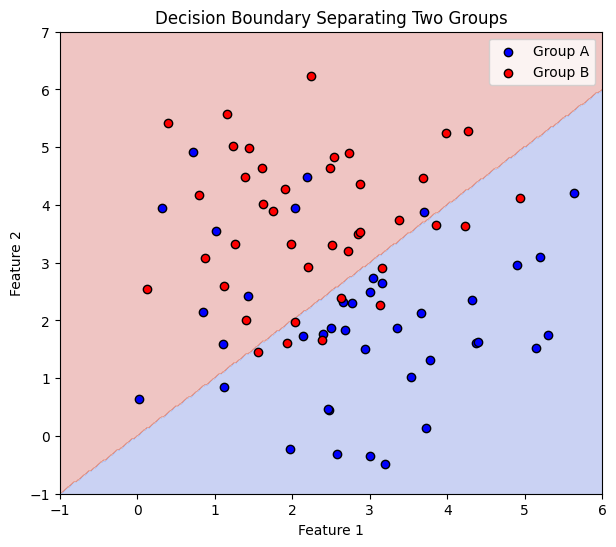

In [19]:
# Building a simple, easy-to-understand fake classifier: "predict Group B if
# feature_2 is greater than feature_1", which draws a simple diagonal boundary.
def simple_classifier(feature_1, feature_2):
    return (feature_2 > feature_1).astype(int)   # 0 = Group A, 1 = Group B

np.random.seed(7)
group_a_x = np.random.normal(3, 1.3, 40)
group_a_y = np.random.normal(2, 1.3, 40)
group_b_x = np.random.normal(2, 1.3, 40)
group_b_y = np.random.normal(4, 1.3, 40)

# Building a fine grid of points covering the whole chart area, so we can
# ask the classifier "what would you predict here?" at every single point.
x_grid, y_grid = np.meshgrid(np.linspace(-1, 6, 300), np.linspace(-1, 7, 300))
predictions_on_grid = simple_classifier(x_grid, y_grid)

fig, ax = plt.subplots(figsize=(7, 6))

# contourf shades the background according to the classifier's prediction at each point
ax.contourf(x_grid, y_grid, predictions_on_grid, alpha=0.3, cmap="coolwarm")

# Now plot the actual data points on top of the shaded regions
ax.scatter(group_a_x, group_a_y, color="blue", label="Group A", edgecolor="black")
ax.scatter(group_b_x, group_b_y, color="red", label="Group B", edgecolor="black")

ax.set_title("Decision Boundary Separating Two Groups")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
plt.show()

### ROC and Precision-Recall curves — evaluating a classifier at every threshold

Most classifiers do not just output "yes" or "no" directly — they output
a PROBABILITY (for example, "I am 73% sure this is spam"), and then we
choose a threshold (commonly 50%) above which we count the answer as
"yes". A ROC curve and Precision-Recall curve both show how the model
performs across EVERY possible threshold, not just the one you happened
to choose.

First, a few simple words you need before reading these charts:

- **True Positive** — the model correctly said "yes" and it really was "yes".
- **False Positive** — the model said "yes" but it was actually "no" (a
  false alarm).
- **False Negative** — the model said "no" but it was actually "yes" (a
  missed case).
- **True Positive Rate (also called Recall)** — out of all the actual
  "yes" cases, what fraction did the model correctly catch?
- **False Positive Rate** — out of all the actual "no" cases, what
  fraction did the model wrongly call "yes"?
- **Precision** — out of everything the model labeled "yes", what
  fraction was actually correct?

**The ROC curve** plots the False Positive Rate (x-axis) against the True
Positive Rate (y-axis) as the threshold changes. A model that is
guessing randomly produces a straight diagonal line; a good model bulges
up and to the left, meaning it catches a lot of true positives while
creating very few false alarms.

**The Precision-Recall curve** plots Recall (x-axis) against Precision
(y-axis) as the threshold changes. This is especially useful when your
"yes" cases are rare, because ROC curves can look overly optimistic on
rare-event problems.


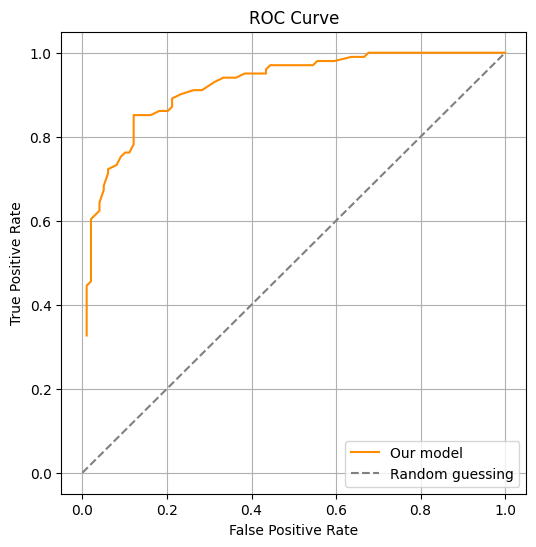

In [20]:
# Simulating fake prediction probabilities for 200 test cases, just for demonstration.
# In a real project, these probabilities would come from your trained model's output,
# and 'true_labels' would come from your actual, correct answers.
np.random.seed(8)
true_labels = np.random.randint(0, 2, 200)   # 0 = negative case, 1 = positive case

# Making the fake probabilities USEFUL (not random) by nudging them toward the
# correct answer, so the resulting curve actually looks like a reasonably good model.
predicted_probabilities = np.clip(
    true_labels * 0.5 + np.random.normal(0.4, 0.25, 200), 0, 1
)

def roc_points(true_labels, predicted_probabilities, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    true_positive_rates = []
    false_positive_rates = []

    for threshold in thresholds:
        predicted_labels = (predicted_probabilities >= threshold).astype(int)

        true_positives = np.sum((predicted_labels == 1) & (true_labels == 1))
        false_positives = np.sum((predicted_labels == 1) & (true_labels == 0))
        false_negatives = np.sum((predicted_labels == 0) & (true_labels == 1))
        true_negatives = np.sum((predicted_labels == 0) & (true_labels == 0))

        tpr = true_positives / (true_positives + false_negatives + 1e-9)
        fpr = false_positives / (false_positives + true_negatives + 1e-9)

        true_positive_rates.append(tpr)
        false_positive_rates.append(fpr)

    return np.array(false_positive_rates), np.array(true_positive_rates)

fpr_values, tpr_values = roc_points(true_labels, predicted_probabilities)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_values, tpr_values, color="darkorange", label="Our model")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guessing")

ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(True)
plt.show()

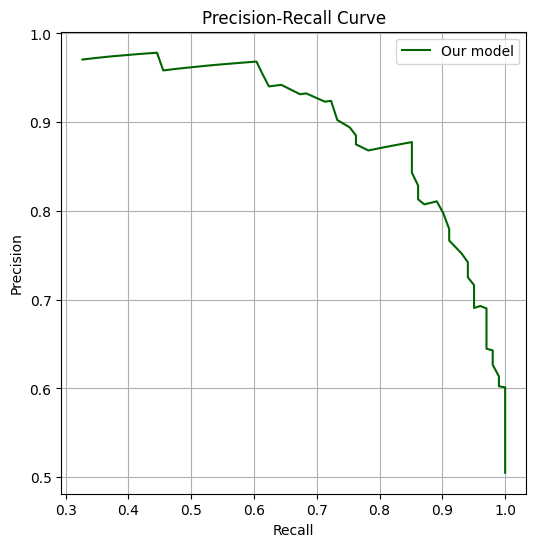

In [21]:
def precision_recall_points(true_labels, predicted_probabilities, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    precisions = []
    recalls = []

    for threshold in thresholds:
        predicted_labels = (predicted_probabilities >= threshold).astype(int)

        true_positives = np.sum((predicted_labels == 1) & (true_labels == 1))
        false_positives = np.sum((predicted_labels == 1) & (true_labels == 0))
        false_negatives = np.sum((predicted_labels == 0) & (true_labels == 1))

        precision = true_positives / (true_positives + false_positives + 1e-9)
        recall = true_positives / (true_positives + false_negatives + 1e-9)

        precisions.append(precision)
        recalls.append(recall)

    return np.array(recalls), np.array(precisions)

recall_values, precision_values = precision_recall_points(true_labels, predicted_probabilities)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(recall_values, precision_values, color="darkgreen", label="Our model")

ax.set_title("Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(True)
plt.show()

**A short summary of how to read these two curves:** a curve that
hugs the top-left corner of the ROC chart, or the top-right corner of the
Precision-Recall chart, represents a strong classifier. A curve sitting
close to the diagonal (in the ROC chart) means the model is barely
better than random guessing.


## 4. Quick Reference Cheat-Sheet

| What you want to do | How to do it |
|---|---|
| Create a Figure with one chart area | `fig, ax = plt.subplots()` |
| Create a Figure with a grid of chart areas | `fig, axes = plt.subplots(rows, cols)` |
| Draw a line plot | `ax.plot(x, y)` |
| Draw a scatter plot | `ax.scatter(x, y)` |
| Draw a histogram | `ax.hist(data, bins=...)` |
| Draw a box plot | `ax.boxplot(data)` |
| Draw a bar chart | `ax.bar(categories, values)` |
| Add a title | `ax.set_title("...")` |
| Label the x-axis / y-axis | `ax.set_xlabel("...")`, `ax.set_ylabel("...")` |
| Show a legend box | `ax.legend()` (needs `label=...` on each plotted item) |
| Turn on gridlines | `ax.grid(True)` |
| Draw a vertical/horizontal reference line | `ax.axvline(x=...)`, `ax.axhline(y=...)` |
| Fix overlapping titles/labels automatically | `plt.tight_layout()` |
| Show the plot | `plt.show()` |
| Save the plot as an image file | `plt.savefig("name.png", dpi=300, bbox_inches="tight")` |
| Display a 2D grid of numbers as a colored image | `ax.imshow(array, cmap="...")` |
| Add a color scale bar next to a heatmap | `plt.colorbar(image, ax=ax)` |
| Shade regions of a chart based on a condition | `ax.contourf(x_grid, y_grid, values)` |
| Build a grid of x/y points to evaluate a function everywhere | `np.meshgrid(x_values, y_values)` |

---

Nearly every chart in this notebook follows the exact same recipe: create
a Figure and Axes with `plt.subplots()`, call one plotting method on the
Axes (`.plot()`, `.scatter()`, `.hist()`, `.boxplot()`, `.imshow()`, or
`.contourf()`), add a title and axis labels so the chart can stand on its
own without extra explanation, and finish with `plt.show()` or
`plt.savefig()`. Once that recipe feels automatic, reading and adapting
any new Matplotlib example you come across becomes far easier.
